In [2]:
import sys
import matplotlib.pyplot as plt
import torch

sys.path.append("/Users/maoyuhui/Desktop/NTU/courses/s2/EE6483/workplace/MiniProject-Dogs-vs.-Cats")

from utils.dataset import DatasetConfig, build_dataloaders, describe_dataset

In [3]:
root_dir = "/Users/maoyuhui/Desktop/NTU/courses/s2/EE6483/workplace/dogs-vs-cats/data"

In [4]:
config = DatasetConfig(
    root_dir=root_dir,
    img_size=224,
    batch_size=8,
    num_workers=0,   # notebook 里先设 0，最稳
    augmentation="light",
    normalize_mode="imagenet",
    train_subset=None,
    val_subset=None,
    seed=42,
)

info = describe_dataset(config)
info

{'root_dir': '/Users/maoyuhui/Desktop/NTU/courses/s2/EE6483/workplace/dogs-vs-cats/data',
 'img_size': 224,
 'augmentation': 'light',
 'normalize_mode': 'imagenet',
 'train_size': 20000,
 'val_size': 5000,
 'test_size': 12500,
 'class_to_idx': {'cat': 0, 'dog': 1}}

In [5]:
train_loader, val_loader, test_loader, class_to_idx = build_dataloaders(config)

print(class_to_idx)

{'cat': 0, 'dog': 1}


In [6]:
train_images, train_labels = next(iter(train_loader))

print("train_images.shape =", train_images.shape)
print("train_labels.shape =", train_labels.shape)
print("train_labels =", train_labels.tolist())

train_images.shape = torch.Size([8, 3, 224, 224])
train_labels.shape = torch.Size([8])
train_labels = [0, 0, 0, 0, 1, 1, 1, 0]


/Users/maoyuhui/anaconda3/envs/lin_alg_py/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [7]:
val_images, val_labels = next(iter(val_loader))

print("val_images.shape =", val_images.shape)
print("val_labels.shape =", val_labels.shape)
print("val_labels =", val_labels.tolist())

val_images.shape = torch.Size([8, 3, 224, 224])
val_labels.shape = torch.Size([8])
val_labels = [0, 0, 0, 0, 0, 0, 0, 0]


In [8]:
test_images, test_ids, test_names = next(iter(test_loader))

print("test_images.shape =", test_images.shape)
print("test_ids =", test_ids.tolist())
print("test_names =", list(test_names))

test_images.shape = torch.Size([8, 3, 224, 224])
test_ids = [1, 2, 3, 4, 5, 6, 7, 8]
test_names = ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg']


In [9]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)
    return img

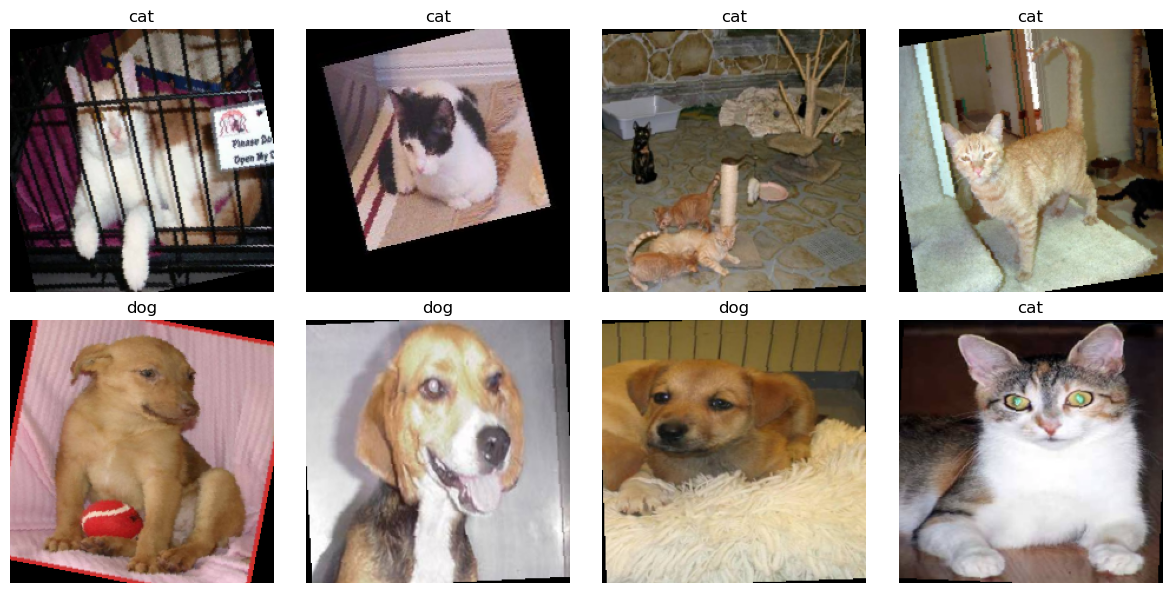

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = denormalize(train_images[i]).permute(1, 2, 0).numpy()
    label = train_labels[i].item()
    label_name = "dog" if label == 1 else "cat"

    axes[i].imshow(img)
    axes[i].set_title(label_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

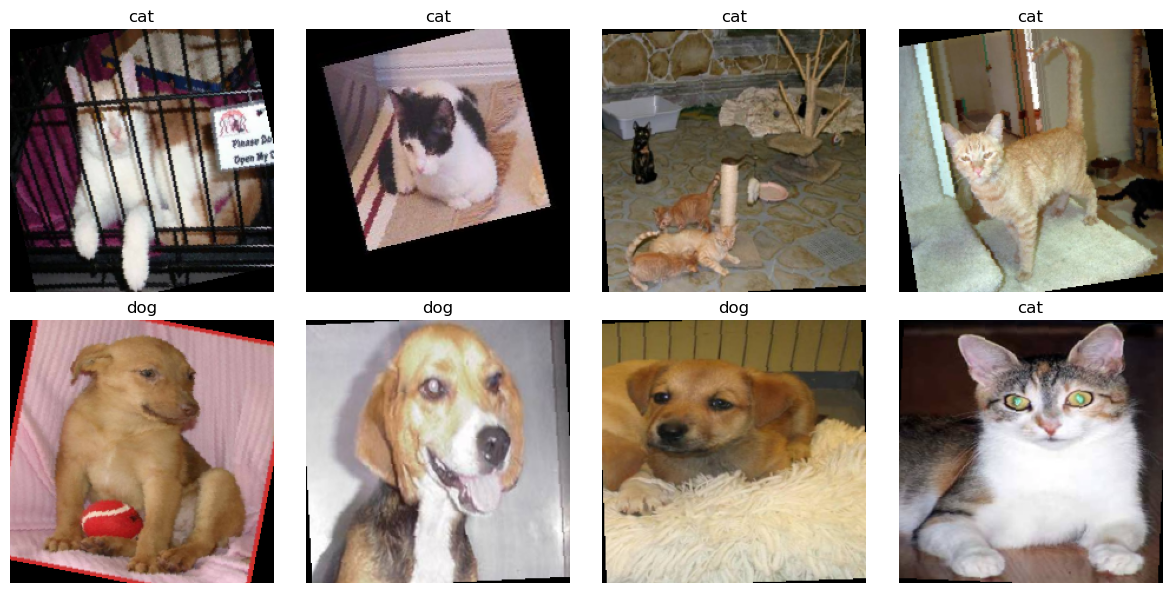

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = denormalize(train_images[i]).permute(1, 2, 0).numpy()
    label = train_labels[i].item()
    label_name = "dog" if label == 1 else "cat"

    axes[i].imshow(img)
    axes[i].set_title(label_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
config_none = DatasetConfig(
    root_dir=root_dir,
    img_size=224,
    batch_size=8,
    num_workers=0,
    augmentation="none",
    seed=42,
)

train_loader_none, _, _, _ = build_dataloaders(config_none)
images_none, labels_none = next(iter(train_loader_none))

print(images_none.shape, labels_none.shape)

torch.Size([8, 3, 224, 224]) torch.Size([8])


In [13]:
config_strong = DatasetConfig(
    root_dir=root_dir,
    img_size=224,
    batch_size=8,
    num_workers=0,
    augmentation="strong",
    seed=42,
)

train_loader_strong, _, _, _ = build_dataloaders(config_strong)
images_strong, labels_strong = next(iter(train_loader_strong))

print(images_strong.shape, labels_strong.shape)

torch.Size([8, 3, 224, 224]) torch.Size([8])


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = denormalize(images_strong[i]).permute(1, 2, 0).numpy()
    label = labels_strong[i].item()
    label_name = "dog" if label == 1 else "cat"

    axes[i].imshow(img)
    axes[i].set_title(label_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()